<a href="https://colab.research.google.com/github/sastha-06/24ADI003_ML_LAB/blob/main/24BAD106_ML_EX9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SCENARIO 1: User-Based Collaborative Filtering (Movie Recommendation System)**

In this experiment, I used the MovieLens ratings dataset to recommend movies to users based on similar users' preferences. I selected features such as userId, movieId, rating, and timestamp, and used the ratings to predict suitable movie recommendations for each user. First, I performed data preprocessing by creating a user-item matrix and handling missing values. Then, I computed user similarity using cosine similarity to identify users with similar rating patterns. Based on the top similar users, I predicted ratings for unseen movies and generated Top-N movie recommendations. I evaluated the model performance using RMSE and MAE error metrics. I also analyzed the sparsity of the user-item matrix and observed how similarity affects recommendation quality. Finally, I visualized the user-item matrix and similarity matrix using heatmaps. From the results, I observed that user-based collaborative filtering can effectively recommend movies, but performance depends on user similarity and data sparsity.

SASTHA JEYASRI A
24BAD106
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

User-Item Matrix Created!

Matrix Sparsity: 0.9835608583913366
Total Users: 671
Total Movies: 9066
Total Ratings: 100004

User Similarity Computed!

Top 5 Similar Users for User 1:
userId
325    0.371852
634    0.194093
341    0.162819
310    0.157524
207    0

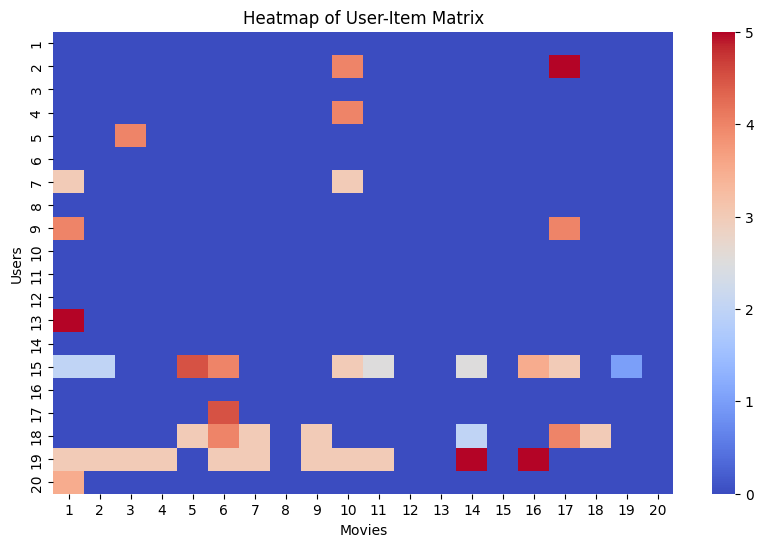

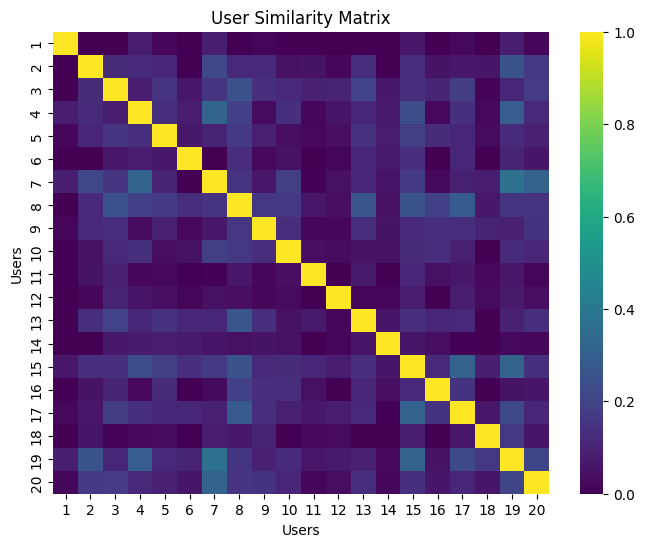

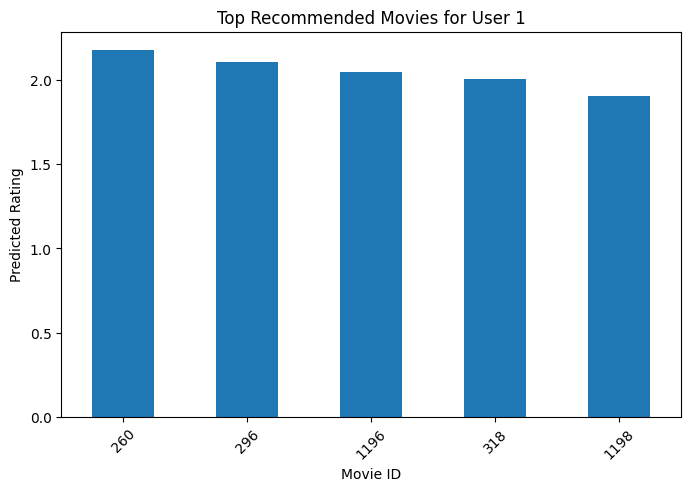

In [14]:
#from google.colab import files
#uploaded = files.upload()

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load Dataset
df = pd.read_csv('ratings.csv')
print("SASTHA JEYASRI A\n24BAD106")
print(df.columns)
print(df.head())
print(df.info())
# CREATE USER-ITEM MATRIX
user_item = df.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values
user_item_filled = user_item.fillna(0)

print("\nUser-Item Matrix Created!")

# SPARSITY ANALYSIS
total_cells = user_item.shape[0] * user_item.shape[1]
filled_cells = df.shape[0]

sparsity = 1 - (filled_cells/total_cells)

print("\nMatrix Sparsity:", sparsity)
print("Total Users:",user_item.shape[0])
print("Total Movies:",user_item.shape[1])
print("Total Ratings:",df.shape[0])

# USER-BASED COLLABORATIVE FILTERING
# Compute similarity
user_similarity = cosine_similarity(user_item_filled)

# Convert to DataFrame
user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_filled.index,
                                 columns=user_item_filled.index)

print("\nUser Similarity Computed!")

# TOP SIMILAR USERS
print("\nTop 5 Similar Users for User 1:")
print(user_similarity_df.loc[1].sort_values(ascending=False)[1:6])

# Predict ratings
def predict_ratings(user_item, similarity):
    mean_user_rating = user_item.mean(axis=1)
    ratings_diff = user_item.sub(mean_user_rating, axis=0)
    pred = mean_user_rating.values.reshape(-1,1) + \
           similarity.dot(ratings_diff.fillna(0)) / \
           np.abs(similarity).sum(axis=1).reshape(-1,1)

    return pred

user_pred = predict_ratings(user_item_filled, user_similarity)

user_pred_df = pd.DataFrame(user_pred,
                           index=user_item_filled.index,
                           columns=user_item_filled.columns)

print("\nUser-Based Prediction Done!")

# TOP-N RECOMMENDATIONS (FIXED FUNCTION)
def recommend_movies(pred_df, user_id, n=5):
    user_ratings = pred_df.loc[user_id]
    already_rated = user_item.loc[user_id][user_item.loc[user_id].notna()].index
    recommendations = user_ratings.drop(already_rated)\
                    .sort_values(ascending=False)\
                    .head(n)

    return recommendations

print("\nTop 5 User-Based Recommendations for User 1:\n")

print(recommend_movies(user_pred_df, user_id=1, n=5))

# EVALUATION (RMSE & MAE)
actual = []
predicted = []

for row in df.itertuples():
    actual.append(row.rating)
    predicted.append(user_pred_df.loc[row.userId,row.movieId])
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nEvaluation Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)

# VISUALIZATION
subset = user_item_filled.iloc[:20, :20]
plt.figure(figsize=(10,6))
sns.heatmap(subset, cmap='coolwarm')
plt.title("Heatmap of User-Item Matrix")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

# User Similarity Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='viridis')
plt.title("User Similarity Matrix")
plt.xlabel("Users")
plt.ylabel("Users")
plt.show()

# Top Recommended Movies Graph
top_movies = recommend_movies(user_pred_df, user_id=1, n=5)
plt.figure(figsize=(8,5))
top_movies.plot(kind='bar')
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.xticks(rotation=45)
plt.show()

**SCENARIO 2: Item-Based Collaborative Filtering (Movie Recommendation System)**

In this experiment, I implemented an item-based collaborative filtering model using the MovieLens ratings dataset to recommend movies based on item similarity. First, I loaded the dataset and created a user-item matrix and an item-user matrix to understand the rating relationships between users and movies. Then I computed item similarity using cosine similarity to find movies with similar rating patterns. Based on these similarities, I predicted ratings and generated top movie recommendations for a selected user. I evaluated the model performance using RMSE and Precision@K metrics. I also compared item-based filtering with user-based filtering and observed that item-based filtering is more stable when the number of users increases. Finally, I visualized the item similarity matrix, top similar movies, and recommendation results using graphs to better understand the recommendation patterns.

SASTHA JEYASRI A
24BAD106
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205

Item-User Matrix Created!

Item Similarity Computed!

Top 5 Recommendations for User 1:

movieId
8823     0.260400
6883     0.255186
59834    0.155729
71876    0.155729
45969    0.155729
Name: 1, dtype: float64

RMSE: 3.202394280941188
Precision@5: 0.0


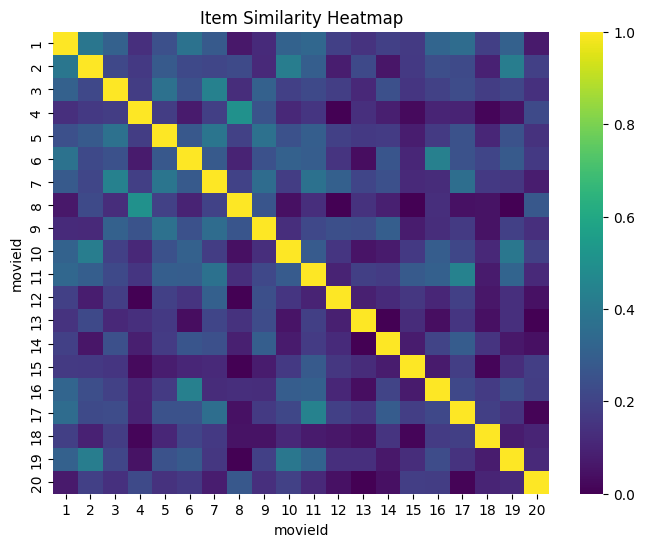


Top 5 similar items:
movieId
3114    0.594710
260     0.576188
356     0.564534
780     0.562946
1265    0.548023
Name: 1, dtype: float64


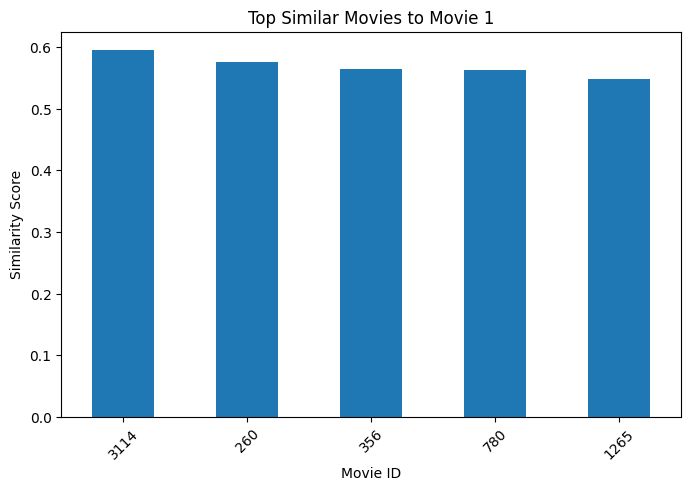

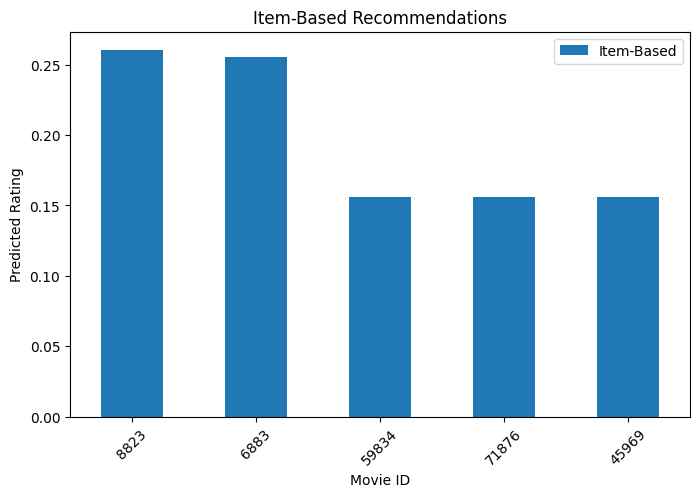


Comparison Between Methods:
User-Based Filtering → recommends based on similar users
Item-Based Filtering → recommends based on similar movies


In [18]:
#from google.colab import files
#uploaded = files.upload()
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# LOAD DATASET
data = pd.read_csv("ratings (1).csv")
print("SASTHA JEYASRI A\n24BAD106")

print(data.head())

# USER-ITEM MATRIX
user_item = data.pivot(index='userId', columns='movieId', values='rating')
user_item_filled = user_item.fillna(0)

item_user = data.pivot(index='movieId', columns='userId', values='rating')

print("\nItem-User Matrix Created!")

# ITEM SIMILARITY
item_similarity = cosine_similarity(user_item_filled.T)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=user_item_filled.columns,
                                 columns=user_item_filled.columns)

print("\nItem Similarity Computed!")

# PREDICT RATINGS
def predict_item_based(user_item, similarity):
    return user_item.dot(similarity) / np.abs(similarity).sum(axis=1)

item_pred = predict_item_based(user_item_filled.values, item_similarity)

item_pred_df = pd.DataFrame(item_pred,
                           index=user_item_filled.index,
                           columns=user_item_filled.columns)

# RECOMMENDATION FUNCTION
def recommend_movies(pred_df, user_id, n=5):

    user_ratings = pred_df.loc[user_id]

    already_rated = user_item.loc[user_id][user_item.loc[user_id].notna()].index

    recommendations = user_ratings.drop(already_rated)\
                    .sort_values(ascending=False)\
                    .head(n)

    return recommendations

print("\nTop 5 Recommendations for User 1:\n")

print(recommend_movies(item_pred_df, user_id=1, n=5))

# RMSE
actual = user_item_filled.values.flatten()

predicted = item_pred_df.values.flatten()

mask = actual > 0

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))

print("\nRMSE:", rmse)

# PRECISION@K
def precision_at_k(pred_df, user_item, user_id, k=5, threshold=3.5):

    recommended = pred_df.loc[user_id]\
                 .sort_values(ascending=False)\
                 .head(k).index

    relevant = user_item.loc[user_id]\
               [user_item.loc[user_id] >= threshold].index

    relevant_recommended = len(set(recommended) & set(relevant))

    return relevant_recommended / k

precision = precision_at_k(item_pred_df,
                           user_item,
                           user_id=1,
                           k=5)

print("Precision@5:", precision)

# ITEM SIMILARITY HEATMAP
plt.figure(figsize=(8,6))

sns.heatmap(item_similarity_df.iloc[:20, :20],
            cmap='viridis')

plt.title("Item Similarity Heatmap")

plt.show()

# TOP SIMILAR ITEMS GRAPH

movie_id = item_similarity_df.index[0]

similar_items = item_similarity_df[movie_id]\
                .sort_values(ascending=False)[1:6]

print("\nTop 5 similar items:")
print(similar_items)
plt.figure(figsize=(8,5))
similar_items.plot(kind='bar')
plt.title(f"Top Similar Movies to Movie {movie_id}")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.xticks(rotation=45)
plt.show()

# RECOMMENDATION COMPARISON CHART

comparison_df = pd.DataFrame({

    'Item-Based': recommend_movies(item_pred_df,
                                   user_id=1,
                                   n=5)

})

comparison_df.plot(kind='bar',
                   figsize=(8,5))

plt.title("Item-Based Recommendations")

plt.xlabel("Movie ID")

plt.ylabel("Predicted Rating")

plt.xticks(rotation=45)

plt.show()

print("\nComparison Between Methods:")
print("User-Based Filtering → recommends based on similar users")
print("Item-Based Filtering → recommends based on similar movies")
